<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Procesado de datos</h1>


<h1>Contenidos</h1>

<div class="alert alert-block alert-info" 
     style="margin-top: 20px; padding-top:0px; padding-bottom:0px;border: 1px solid #d60e8c; border-radius: 20px; background:transparent;">
    <ol>
        <li><a href="#intro">Introducción</a></li>
        <li><a href="#about_dataset">Descripción del conjunto de datos</a></li>
        <li><a href="#analysis">Lectura y análisis de los datos </a></li>
        <li><a href="#division">División del conjunto de datos en datos en entrada y salida</a></li>
        <li><a href="#split">División de los datos para entrenamiento y prueba</a></li>
        <li><a href="#oversampling">Balanceo de datos</a></li>
        <li><a href="#scale">Normalización</a></li>        
        <li><a href="#pca">PCA</a></li>        
        <li><a href="#classification">Ejercicio</a></li>
    </ol>
</div>
<br>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Introducción</h1>
<hr style="border: 0.5px solid #d60e8c;">

El objetivo de esta práctica es realizar un informe técnico que analice el funcionamiento de al menos dos técnicas de aprendizaje supervisado sobre un conjunto de datos etiquetados, de modo que se pueda realizar una caracterización objetiva de su funcionamiento en base a los resultados obtenidos.

## Importamos las librerías

Comenzamos importando las librerías que utilizaremos:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import preprocessing
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

<a name="about_dataset"></a>
<h1 style="color: #d60e8c;">Descripción del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

Utilizaremos un conjunto de datos sobre setas laminadas. Todos los atributos se definen mediante palabras o texto. Los datos fueron recolectados 
de la "Guía de campo de la Sociedad Audubon". 
<br><br>
El conjunto de datos original incluye descripciones de muestras hipotéticas correspondientes a 23 especies de setas con láminas de la familia Agaricus y Lepiota (pp. 500-525). Cada especie se identifica como claramente comestible o claramente venenosa en función de las siguientes cualidades:
<ul>
    <li><b>poisonous</b>: si es una seta venenosa o comestible </li> 
    <li><b>cap-shape</b>: forma de la gorra de la seta</li>
    <li><b>cap-surface</b>: tipo de superficie de la gorra de la seta</li>
    <li><b>cap-color</b>: color de la gorra de la seta</li>
    <li><b>bruises</b>: hematomas</li>
    <li><b>odor</b>: olor</li>
    <li><b>gill-attachment</b>: fijación de las branquias </li>
    <li><b>gill-spacing</b>: separación entre las branquias </li>
    <li><b>gill-size</b> tamaño de las branquias</li>
    <li><b>gill-color</b>: color de las branquias</li>
    <li><b>stalk-shape</b>: forma del tallo</li>
    <li><b>stalk-root</b>: raiz del tallo </li>    
    <li><b>stalk-surface-above-ring</b>: superficie del tallo por encima del anillo</li>
    <li><b>stalk-surface-below-ring</b>: superficie del tallo por debajo del anillo</li>
    <li><b>stalk-color-above-ring</b>: color del tallo por encima del anillo</li>
    <li><b>stalk-color-below-ring</b>: color del tallo por debajo del anillo</li>
    <li><b>veil-type</b>: tipo de velo </li>   
    <li><b>veil-color</b>: color del velo </li>
    <li><b>ring-number</b>: numero de anillos </li> 
    <li><b>ring-type</b>: tipo de anillos </li>
    <li><b>spore-print-color</b>: color de la huella de esporas </li>  
    <li><b>population</b>: rareza y facilidad para encontrarlas </li> 
    <li><b>habitat</b>: habitat en el que crecen</li>       

</ul>

[Enlace al repositorio](https://archive.ics.uci.edu/dataset/73/mushroom)

<a name="analysis"></a>
<h1 style="color: #d60e8c;">Lectura y análisis de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

El archivo con el conjunto de datos tiene valores perdidos en el dataset, con lo que, cuando leemos el archivo, indicamos que existen valores perdidos con <code>na_values=["?"]</code> (de esta forma, estamos indicando que los valores perdidos están representados por el carácter "?"). Así, en la lectura del archivo, esos valores las celdas que contengan el valor "?" serán convertidas a valores nulos, posteriormente se filtrarán.

In [2]:
df_orig=pd.read_csv('mushroms1.csv', na_values=["?"])
df_orig.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
1,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
2,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
3,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
4,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,BROWN,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS


## Eliminación de filas con información incompleta

1. Se consultan las dimensiones del conjunto de datos:

In [3]:
df_orig.shape

(8417, 23)

2. Se obtienen los valores nulos que tenememos en cada columna: sabemos que existen porque en la lectura del archivo, hemos indicado que el conjunto de datos contiene valores perdidos para que los convirtiese en nulos en la lectura. Vemos que tenemos bastantes valores nulos en la columna **stalk-root** y 1 valor nulo en todas las columnas menos en la columna de **poisonous**.

In [4]:
df_orig.isnull().sum()

poisonous                      0
cap-shape                      1
cap-surface                    1
cap-color                      1
bruises                        1
odor                           1
gill-attachment                1
gill-spacing                   1
gill-size                      1
gill-color                     1
stalk-shape                    1
stalk-root                  2481
stalk-surface-above-ring       1
stalk-surface-below-ring       1
stalk-color-above-ring         1
stalk-color-below-ring         1
veil-type                      1
veil-color                     1
ring-number                    1
ring-type                      1
spore-print-color              1
population                     1
habitat                        1
dtype: int64

3. Se eliminan las filas que contienen algún valor nulo en alguna de sus columnas, ya que tienen información incompleta.

In [5]:
df=df_orig.dropna(axis=0)

4. Se consultan las dimensiones del dataset tras eliminar las filas con valores nulos.

In [6]:
df.shape

(5936, 23)

5. Se consulta de nuevo los valores nulos para verificar que ya no existen. Ahora el resultado debería ser 0 para todas las columnas.

In [7]:
df.isnull().sum()

poisonous                   0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

6. Ahora se comprobará que tenemos unos valores de la columna de **poisonous** equilibrados entre setas comestibles y venenosas:

In [8]:
df['poisonous'].value_counts()

poisonous
EDIBLE       3768
POISONOUS    2168
Name: count, dtype: int64

<a name="division"></a>
<h1 style="color: #d60e8c;">Transformación de los valores del conjunto de datos de texto a número</h1>
<hr style="border: 0.5px solid #d60e8c;">

Para poder trabajar con el conjunto de datos que hemos analizado y ajustado anteriormente, es necesario pasar todos los valores que sean de texto en alguna columna a número para evitar errores y poder implementar el método utilizado en clase.

A continuación se incluye el código completo con el que se han ido transformando todos los valores a número, además de a qué número le corresponde cada palabra:

In [9]:
encoder = preprocessing.OrdinalEncoder(dtype=int)
df_encoded = encoder.fit_transform(df[['poisonous', "cap-shape","cap-surface","cap-color","bruises","odor",
                                      "gill-attachment","gill-spacing","gill-size","gill-color","stalk-shape","stalk-root",
                                      "stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring",
                                      "stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type",
                                      "spore-print-color","population","habitat"]])
encoder.categories_

[array(['EDIBLE', 'POISONOUS'], dtype=object),
 array(['BELL', 'CONICAL', 'CONVEX', 'FLAT', 'KNOBBED', 'SUNKEN'],
       dtype=object),
 array(['FIBROUS', 'GROOVES', 'SCALY', 'SMOOTH'], dtype=object),
 array(['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'PINK', 'RED', 'WHITE',
        'YELLOW'], dtype=object),
 array(['BRUISES', 'NO'], dtype=object),
 array(['ALMOND', 'ANISE', 'CREOSOTE', 'FOUL', 'MUSTY', 'NONE', 'PUNGENT'],
       dtype=object),
 array(['ATTACHED', 'FREE'], dtype=object),
 array(['CLOSE', 'CROWDED'], dtype=object),
 array(['BROAD', 'NARROW'], dtype=object),
 array(['BLACK', 'BROWN', 'CHOCOLATE', 'GRAY', 'GREEN', 'PINK', 'PURPLE',
        'WHITE', 'YELLOW'], dtype=object),
 array(['ENLARGING', 'TAPERING'], dtype=object),
 array(['BULBOUS', 'CLUB', 'EQUAL', 'ROOTED'], dtype=object),
 array(['FIBROUS', 'SCALY', 'SILKY', 'SMOOTH'], dtype=object),
 array(['FIBROUS', 'SCALY', 'SILKY', 'SMOOTH'], dtype=object),
 array(['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'PINK', 'WHITE', 'YELLOW'],

Este es el texto presente en el archivo .csv, y acontinuación se mostrarán las correspondencias numéricas:

In [10]:
df_encoded

array([[0, 2, 3, ..., 4, 4, 5],
       [0, 2, 3, ..., 1, 4, 5],
       [0, 2, 3, ..., 4, 4, 5],
       ...,
       [0, 3, 2, ..., 5, 4, 3],
       [0, 3, 2, ..., 5, 5, 3],
       [0, 3, 2, ..., 5, 4, 3]], shape=(5936, 23))

In [11]:
df["poisonous"] = df_encoded[:,0]
df["cap-shape"] = df_encoded[:,1]
df["cap-surface"] = df_encoded[:,2]
df["cap-color"] = df_encoded[:,3]
df["bruises"] = df_encoded[:,4]
df["odor"] = df_encoded[:,5]
df["gill-attachment"] = df_encoded[:,6]
df["gill-spacing"] = df_encoded[:,7]
df["gill-size"] = df_encoded[:,8]
df["gill-color"] = df_encoded[:,9]
df["stalk-shape"] = df_encoded[:,10]
df["stalk-root"] = df_encoded[:,11]
df["stalk-surface-above-ring"] = df_encoded[:,12]
df["stalk-surface-below-ring"] = df_encoded[:,13]
df["stalk-color-above-ring"] = df_encoded[:,14]
df["stalk-color-below-ring"] = df_encoded[:,15]
df["veil-type"] = df_encoded[:,16]
df["veil-color"] = df_encoded[:,17]
df["ring-number"] = df_encoded[:,18]
df["ring-type"] = df_encoded[:,19]
df["spore-print-color"] = df_encoded[:,20]
df["population"] = df_encoded[:,21]
df["habitat"] = df_encoded[:,22]
df.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,4,4,5
1,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,1,4,5
2,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,4,4,5
3,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,1,4,5
4,0,2,3,6,0,0,1,1,1,1,...,3,5,5,0,0,1,3,4,4,5


<a name="division"></a>
<h1 style="color: #d60e8c;">División del conjunto de datos en datos de entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


Se obtienen los atributos que caracterizan nuestro conjunto de datos:

In [12]:
df.columns

Index(['poisonous', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

Se seleccionan las columnas que utilizaremos como entradas y las convertimos en un <b>array de NumPy</b>, para poder utilizarlo con los algoritmos de <b>scikit-learn</b>:

In [13]:
feature_df = df[df.columns[1:df.shape[1]]]
# Usando DataFrame Pandas
X = feature_df
X_readed = np.asarray(feature_df)
X_readed[0:5]
feature_df.shape

(5936, 22)

Y ahora los datos de salida, si la seta es venenosa o no:

In [14]:
y_readed = np.asarray(df['poisonous'])
y_readed[0:5]

array([0, 0, 0, 0, 0])

<a name="split"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 75% del conjunto de datos para entrenar el modelo y el 25% para test (valores por defecto si no se fijan el tamaño en los parámetros), ya que tenemos una gran cantidad de datos, se considera que no es necesario utilizar más del 75% de los datos para obtener unos resultados fiables.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_readed, y_readed, random_state = 1)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4452, 22) (4452,)
Test set: (1484, 22) (1484,)


<a name="oversampling"></a>
<h1 style="color: #d60e8c;">Balanceo de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

Como hemos podido observar anteriormente, la cantidad de valores en la columna de **poisonous** que se corresponden con setas comestibles y con setas venenosas es muy notable, siendo su diferencia del orden de 1600, siendo su representación de un 63% de setas comestibles y un 37% de setas venenosas. Esto puede influir en la capacidad del algoritmo para predecir correctamente la clase minoritaria, ya que al estar menos representada este puede ignorarla, haciendo que el calculo de la precisión del modelo no se asemeje completamente a la realidad.

Por lo tanto, para corregir esto, se utiliza la librería <a href="https://imbalanced-learn.org/stable/index.html"><b>imbalanced-learn</b></a> para realizar el balanceo del conjunto de datos, quitando muestras en los casos mayoritarios para obtener el conjunto final sobre el que se trabajará:

In [ ]:

unique, counts = np.unique(y_train, return_counts=True)
sm = NearMiss()
X_train, y_train= sm.fit_resample(X_train, y_train)

print('\nBalanceado undersampling:', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


Balanceado: (3248, 22) (3248,)
{np.int64(0): np.int64(1624), np.int64(1): np.int64(1624)}


Por otro lado, también se comprobará cual es el resultado obtenido final si añadimos muestras al caso minoritario hasta igualar ambas partes del conjunto de datos:

In [16]:
unique, counts = np.unique(y_train, return_counts=True)
sm = SMOTE(random_state=1)
X_train, y_train= sm.fit_resample(X_train, y_train)

print('\nBalanceado oversampling:', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


Balanceado oversampling: (5656, 22) (5656,)
{np.int64(0): np.int64(2828), np.int64(1): np.int64(2828)}


<a name="scale"></a>
<h1 style="color: #d60e8c;">Normalización</h1>
<hr style="border: 0.5px solid #d60e8c;">

Ahora se procederá a realizar la normalización del conjunto de datos, esto permitirá evitar que los algoritmos tengan un sesgo y aprendan mejor unas características que otras, buscando que estos datos sigan una distribución normal. Para ello, se transforman los datos para centrarlos eliminando el valor medio de cada característica y a continuación se escalan dividiendo las características por su desviación estándar. 

Como la librería <code>scikit-learn</code> dispone de un módulo para procesado de datos <code>preprocessing</code>. Vamos a utilizar <code>StandardScaler</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler">documentación</a>).  Que, una vez entrenado, se puede utilizar posteriormente sobre nuevos datos.


In [ ]:
scaler = preprocessing.StandardScaler(with_mean=False, with_std=False)
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_train[0:5]

array([[-0.47249194,  1.24467976, -0.35202293,  0.97210049,  0.82672739,
         0.07890913,  2.10925112, -0.41617374, -1.61224073,  1.11275655,
         1.56637241, -2.51242846, -2.35993996,  0.70229149,  0.71960475,
         0.        , -0.0376355 , -0.06156334, -1.63941352, -0.21129726,
        -0.50457818, -1.234582  ],
       [ 0.89237753,  0.41965823, -1.59151763, -1.02870023, -2.37117311,
         0.07890913, -0.47410192, -0.41617374, -1.17383527, -0.89866916,
         2.66952299,  0.67397457, -1.33302656,  0.70229149,  0.71960475,
         0.        , -0.0376355 , -0.06156334,  0.86848123, -1.12637944,
         1.02607035,  0.11884786],
       [-0.47249194,  1.24467976,  0.88747178, -1.02870023, -2.37117311,
         0.07890913,  2.10925112,  2.40284263,  0.57978657,  1.11275655,
        -0.63992876,  0.67397457,  0.72080025,  0.70229149,  0.71960475,
         0.        , -0.0376355 , -0.06156334,  0.86848123, -0.21129726,
         0.26074609,  1.02113443],
       [-3.20223089

<a name="pca"></a>
<h1 style="color: #d60e8c;">PCA</h1>
<hr style="border: 0.5px solid #d60e8c;">

Aplicando el Análisis de componentes principales (PCA) se tratará de buscar conjuntos de ejes de coordenadas en los que algunas de las dimensiones no sean necesarias utilizando algoritmos que centren los ejes en el origen de coordenadas restando la media.

Para aplicar el Análisis de componentes principales (PCA) se utilizará el algoritmo <code>PCA</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA">documentación del algoritmo</a>) implementado la librería <code>scikit-learn</code> sobre el conjunto de datos. Antes de utilizar PCA para extraer **n** componentes principales, lo utilizaresmos sin parámetros de forma que podemos analizar el porcentaje de varianza de todos los componentes utilizando "explained_variance_ratio_", que devuelve una lista, en este caso con 22 elementos porque vamos a usar los trece atributos, donde cada elemento de la lista indica el porcentaje de variabilidad que representa ese componente y, como utilizamos todos los componentes, la suma de todos los porcentajes, es decir, la suma de todos los elementos de la lista dará 1 como resultado.


In [18]:
mypca = PCA()
mypca.fit(X_train)

mypca.explained_variance_ratio_

array([0.24185777, 0.14224062, 0.08659908, 0.08088857, 0.06401374,
       0.05767656, 0.0447481 , 0.04121977, 0.03572028, 0.03225732,
       0.03128393, 0.02815225, 0.02269381, 0.01785345, 0.01776416,
       0.01579183, 0.01457732, 0.0113402 , 0.00863417, 0.00272329,
       0.00196379, 0.        ])

In [19]:
mypca.explained_variance_ratio_.sum()  # Suma todos los elementos de la lista

np.float64(0.9999999999999997)

A partir de <code>explained_variance_ratio_</code>, podemos calcular la varianza acumulada de los componentes:</li>   


In [20]:
print("\n Varianza que aporta cada componente:")
variance = mypca.explained_variance_ratio_
print(variance)

print("\n Varianza acumulada:")
acumvar = variance.cumsum()

for i in range(len(acumvar)):
    print(f" {(i+1):2} componentes: {acumvar[i]:.8f} ")



 Varianza que aporta cada componente:
[0.24185777 0.14224062 0.08659908 0.08088857 0.06401374 0.05767656
 0.0447481  0.04121977 0.03572028 0.03225732 0.03128393 0.02815225
 0.02269381 0.01785345 0.01776416 0.01579183 0.01457732 0.0113402
 0.00863417 0.00272329 0.00196379 0.        ]

 Varianza acumulada:
  1 componentes: 0.24185777 
  2 componentes: 0.38409839 
  3 componentes: 0.47069747 
  4 componentes: 0.55158604 
  5 componentes: 0.61559978 
  6 componentes: 0.67327634 
  7 componentes: 0.71802444 
  8 componentes: 0.75924421 
  9 componentes: 0.79496449 
 10 componentes: 0.82722181 
 11 componentes: 0.85850574 
 12 componentes: 0.88665799 
 13 componentes: 0.90935180 
 14 componentes: 0.92720524 
 15 componentes: 0.94496941 
 16 componentes: 0.96076123 
 17 componentes: 0.97533856 
 18 componentes: 0.98667875 
 19 componentes: 0.99531292 
 20 componentes: 0.99803621 
 21 componentes: 1.00000000 
 22 componentes: 1.00000000 


<h3>Projección PCA con 2 componentes</h3>
Ahora vamos a utilizar PCA para extraer dos componentes y visualizar el resultado en una gráfica, así como calcular la pérdida de información respecto al conjunto original con los 22 atributos de entrada.

In [21]:
mypca2 = PCA(n_components=2)
mypca2.fit(X_train)
values_proj2 = mypca2.transform(X_train)


Con la función <code>inverse_transform</code> se reconstruye el conjunto de datos de los <code>n</code> componentes principales (2 componentes, en este caso), y calcula la pérdida de información respecto al conjunto original. Para calcular esa pérdida, se puede calcular el promedio de las diferencias elevadas al cuadrado entre cada elemento del conjunto reconstruido y el original. Si sumamos el valor de pérdida obtenido al porcentaje de la varianza acumulada con dos componentes, vemos que el resultado es 1.

In [22]:
X_projected2 = mypca2.inverse_transform(values_proj2)
loss2 = ((X_train - X_projected2) ** 2).mean()
print("Projection loss (2 components): " + str(loss2))

Projection loss (2 components): 0.5879060837007153


Vamos ahora a mostrar la gráfica de la distribución de los datos origninales con los dos primeros atributos y la proyección PCA con 2 componentes componentes principales. En ambos casos, se utilizan dos dimensiones:

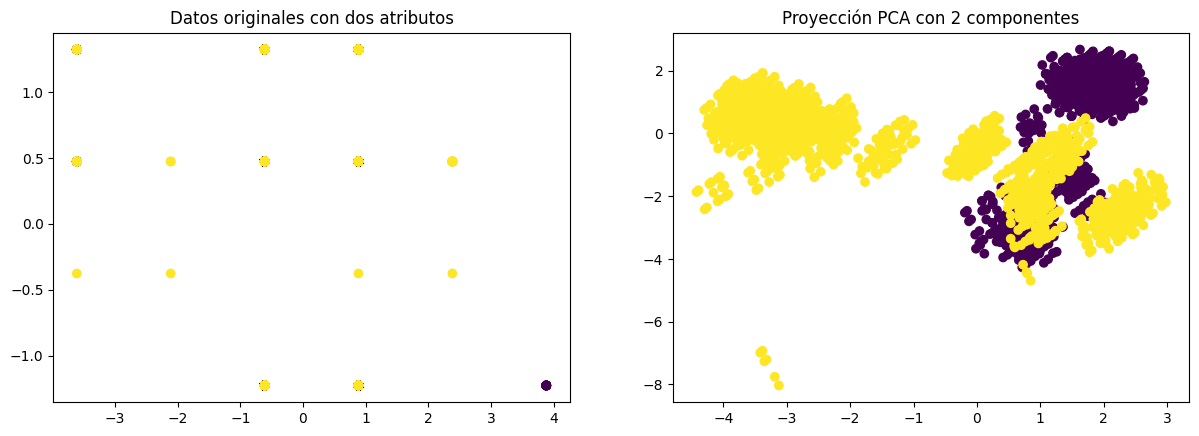

In [23]:
plt.figure()
plt.subplot(1,2,1) # 1 - numrows, 2 - numcols, 1 - index
plt.title("Datos originales con dos atributos")
plt.scatter(X_train[: ,0] , X_train[: ,1] ,marker='o' ,c=y_train)
plt.subplot(1,2,2) # 1 - numrows, 2 - numcols, 2 - index
plt.scatter(values_proj2[: ,0] , values_proj2[: ,1],marker='o' ,c=y_train)
plt.title("Proyección PCA con 2 componentes")
plt.subplots_adjust(right=1.9) # Distancia a la derecha
plt.show()


**Conclusión:**<br>
Si intentamos visualizar los datos con dos variables al azar, el resultado que obtenemos no nos proporciona información sobre la distribución en clases de los datos, como ocurre en la gráfica de la izquierda. 

Sin embargo, si se visualizan los datos en base a 2 componentes, para este caso, todavía se pueden observar datos bastante mezclados con un **projection loss** de 0.5879, un valor de perdidas demasiado alto, es por ello, que se decide realizar cálculos con más componentes para evitar perdidas muy grandes de datos. Además, en este caso, tras ver los resultados de la varianza obtenida con cada componente, para obtener una mejor separación entre clases necesitaríamos llegar a 12-13 componentes, pero no podemos visualizarlo gráficamente, ya que serían 12-13 dimensiones a representar.

<h3>Projección con 13 componentes</h3>

In [24]:
mypca13 = PCA(n_components=15)
mypca13.fit(X_train)
values_proj13 = mypca13.transform(X_train)

X_projected13 = mypca13.inverse_transform(values_proj13)
loss13 = ((X_train - X_projected13) ** 2).mean()

print("Projection loss (13 components): " + str(loss13))




Projection loss (13 components): 0.05252920184300113


Una vez realizadas varias pruebas, se puede observar que, a partir de 13 componentes, las perdidas de información se reducen a valores inferiores al 10%, por lo que se considera recomendable aplicar un PCA a como mínimo 13 componentes.

<a name="classification"></a>
# <font style="color:#d60e8c;">Clasificación</font>
<hr style="border: 0.5px solid #d60e8c;">

## KNN

Ahora, será importante determinar el número de vecinos que queremos considerar a la hora de hacer predicciones. Se estudiarán dos casos, un valor de k alto, muy estable y poco sensible al ruido aunque puede perder detalles, o un valor de k bajo que es un modelo flexible y que se adapta muy bien a variaciones y detalles, pero es muy sensible al ruido.

In [22]:
Score = np.zeros(95)
Posicion = np.zeros(95)
Time = np.zeros(95)
for i in range(5,100):
    k = i   # Número de vecinos
    Score_ind=np.zeros(5)
    Posicion_ind=np.zeros(5)
    Time_ind=np.zeros(5)
    for u in range (1,6):
        ini = time.time()
        # Creamos nuestra instancia de nuestro algoritmo KNN con K vecinos
        neigh = KNeighborsClassifier(n_neighbors = k)
        neigh.fit(X_train,y_train)
        y_predict_knn = neigh.predict(X_test)
        # print("Exactitud media obtenida con k-NN: " , neigh.score(X_test, y_test))
        Time_ind[u-1] = (time.time() - ini)*1000
        Score_ind[u-1] = neigh.score(X_test, y_test)
        Posicion_ind[u-1] = i
    Time[i-5] = np.max(Time_ind)
    Score[i-5] = np.max(Score_ind)
    Posicion[i-5] = i
    print(f"Tiempo entrenamiento para k={i}  = {Time[i-5]} ms") 
    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

Tiempo entrenamiento para k=5  = 129.45246696472168 ms
Exactitud media obtenida con k-NN para k=5:  0.5141509433962265
Tiempo entrenamiento para k=6  = 133.0265998840332 ms
Exactitud media obtenida con k-NN para k=6:  0.5242587601078167
Tiempo entrenamiento para k=7  = 133.60047340393066 ms
Exactitud media obtenida con k-NN para k=7:  0.5121293800539084
Tiempo entrenamiento para k=8  = 132.64226913452148 ms
Exactitud media obtenida con k-NN para k=8:  0.5296495956873315


KeyboardInterrupt: 

In [48]:
Valor_maximo = np.max(Score)
Tiempo_min = np.min(Time)
print(f"El valor máximo de exactitud es de: {Valor_maximo}")
print(f"Y está situado en la posición: {Score.argmax()}")
print(f"El valor mínimo de tiempo es de: {Tiempo_min}")
print(f"Y está situado en la posición: {Time.argmin()}")

El valor máximo de exactitud es de: 0.9636118598382749
Y está situado en la posición: 17
El valor mínimo de tiempo es de: 42.375802993774414
Y está situado en la posición: 15


Aquí se puede observar un detalle muy llamativo, si se decide realizar una normalización de los datos, la exactitud que es capaz de conseguir el modelo es de un máximo del 57%, mientras que sin realizar esta normalización este valor asciende al 98%.

### Entrenamiento
Utilizaremos el algoritmo <code>KNeighborsClassifier</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier">documentación del algoritmo</a>).

In [49]:
k = Score.argmax()    # Número de vecinos

# Creamos nuestra instancia de nuestro algoritmo KNN con 4 vecinos
neigh = KNeighborsClassifier(n_neighbors = k, weights='distance')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
neigh.fit(X_train,y_train)
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

Tiempo entrenamiento = 1.714 ms


### Predicción
Ahora podemos utilizar nuestro modelo entrenado para realizar predicciones, para ello llamamos al método <code>predict</code> con el conjunto de valores que hemos reservado para test:

In [50]:
ini = time.time() 
y_predict_knn = neigh.predict(X_test)
print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

y_predict_knn[0:5] # muestra del resultado de la predicción

Tiempo de predicción = 59.762 ms


array([0, 0, 0, 1, 0])

## Matriz de confusión

Se muestra a continuación la matriz de confusión ya que esta gráfica nos permite ver fácilmente el número de elemetos que los algoritmos han clasificado correcta e incorrectamente. Para mostrarla utilizamos <code>ConfusionMatrixDisplay</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html">documentación</a>).


In [31]:
cm_kNN = confusion_matrix(y_test, y_predict_knn, labels=[0,1])
cm_kNN

array([[808, 132],
       [507,  37]])

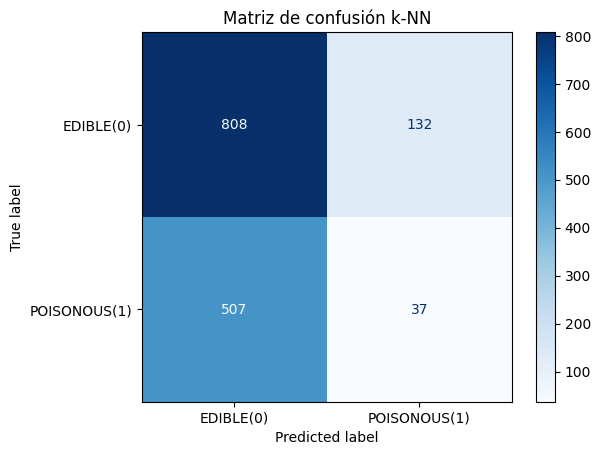

In [32]:

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_kNN,
    display_labels=['EDIBLE(0)','POISONOUS(1)']
)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión k-NN")
plt.show()

## SVM

Ahora se entrenará el modelo SVM con los datos obtenidos anteriormente. Para ello realizaremos 2 estudios, el primero consistirá en cambiar el valor de C en el rango de 1-10 para ver de que manera varian los resultados obtenidos, y el segundo será cambiando el tipo de kernel utilizado para tratar de obtener los mejores resultados con nuestro código.

El parametro C es es que controla el peso de los terminos de error, es decir, indica cuanto castiga la SVM los errores de clasificación. Esto quiere decir que con un valor de C alto el sistema será más sensible al ruido y tendrá una tendencia a sobreajustar, lo que lo hace menos fiable en otros conjuntos de datos. Sin embargo para un valor de C bajo el modelo tenderá más a ignorar el ruido presente en el conjunto, pero tiene una mayor tendencia a no capturar bien estructuras complejas. A continuación se harán unos cálculos para cada modelo para poder observar cual es el mejor caso.

### kernel linear

Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

Una función kernel lineal es la función más simple de todas, esta buscará realizar una frontera lineal para separar las clases.

In [90]:
Score_linear = np.zeros(10)
Posicion_linear = np.zeros(10)
Time_linear = np.zeros(10)
for i in range(1,11):
    Score_ind=np.zeros(5)
    Posicion_ind=np.zeros(5)
    Time_ind=np.zeros(5)
    for u in range (1,6):
        ini = time.time() 
        clf_svm = svm.SVC(C=i,kernel='linear')
        clf_svm.fit(X_train, y_train) 
        y_predict_svm = clf_svm.predict(X_test)
        Score_ind[u-1] = clf_svm.score(X_test, y_test)
        Posicion_ind[u-1] = i
        Time_ind[u-1] = (time.time() - ini)*1000
    Time_linear[i-1] = np.max(Time_ind)
    Score_linear[i-1] = np.max(Score_ind)
    Posicion_linear[i-1] = i
    print(f"Tiempo entrenamiento para C={i}  = {Time_linear[i-1]} ms") 
    print("Exactitud media obtenida con SVM para C={i}: ".format(i=i), clf_svm.score(X_test, y_test))

Tiempo entrenamiento para C=1  = 27.092933654785156 ms
Exactitud media obtenida con SVM para C=1:  0.8254716981132075
Tiempo entrenamiento para C=2  = 29.02364730834961 ms
Exactitud media obtenida con SVM para C=2:  0.8254716981132075
Tiempo entrenamiento para C=3  = 25.45022964477539 ms
Exactitud media obtenida con SVM para C=3:  0.8591644204851752
Tiempo entrenamiento para C=4  = 31.803369522094727 ms
Exactitud media obtenida con SVM para C=4:  0.9076819407008087
Tiempo entrenamiento para C=5  = 33.368825912475586 ms
Exactitud media obtenida con SVM para C=5:  0.9265498652291105
Tiempo entrenamiento para C=6  = 31.24856948852539 ms
Exactitud media obtenida con SVM para C=6:  0.942722371967655
Tiempo entrenamiento para C=7  = 35.77065467834473 ms
Exactitud media obtenida con SVM para C=7:  0.9467654986522911
Tiempo entrenamiento para C=8  = 38.31768035888672 ms
Exactitud media obtenida con SVM para C=8:  0.9467654986522911
Tiempo entrenamiento para C=9  = 48.10070991516113 ms
Exactitu

In [91]:
Valor_maximo = np.max(Score_linear)
Tiempo_min = np.min(Time_linear)

print(f"El valor máximo de exactitud es de: {Valor_maximo}")
print(f"Y está situado en la posición: {Score_linear.argmax()}")
print(f"El valor mínimo de tiempo es de: {Tiempo_min}")
print(f"Y está situado en la posición: {Time_linear.argmin()}")

clf_svm = svm.SVC(C=Score_linear.argmax(),kernel='linear')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

El valor máximo de exactitud es de: 0.9777628032345014
Y está situado en la posición: 9
El valor mínimo de tiempo es de: 25.45022964477539
Y está situado en la posición: 2
Tiempo entrenamiento = 45.791 ms


### Entrenamiento
Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

In [ ]:
clf_svm = svm.SVC(C=(Score_linear.argmax())+1,kernel='linear')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms")

Tiempo entrenamiento = 45.135 ms


### Predicción
Ahora podemos utilizar nuestro modelo entrenado para realizar predicciones, para ello llamamos al método <code>predict</code> con el conjunto de valores que hemos reservado para test:

In [79]:
ini = time.time() 
y_predict_svm = clf_svm.predict(X_test)
print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

y_predict_svm [0:5] # muestra del resultado de la predicción

Tiempo de predicción = 2.867 ms


array([0, 0, 0, 1, 0])

## Matriz de confusión

Se muestra a continuación la matriz de confusión ya que esta gráfica nos permite ver fácilmente el número de elemetos que los algoritmos han clasificado correcta e incorrectamente. Para mostrarla utilizamos <code>ConfusionMatrixDisplay</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html">documentación</a>).

In [80]:
cm_SVM = confusion_matrix(y_test, y_predict_svm, labels=[0,1])
cm_SVM

array([[902,  38],
       [  6, 538]])

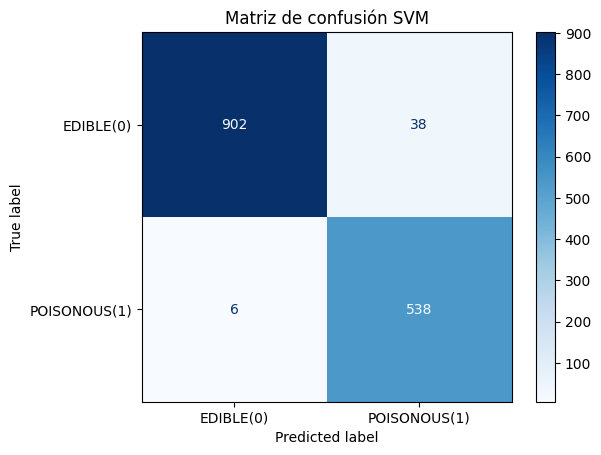

In [81]:
disp_SVM = ConfusionMatrixDisplay(
    confusion_matrix=cm_SVM,
    display_labels=['EDIBLE(0)','POISONOUS(1)']
)
disp_SVM.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión SVM")
plt.show()

### Conclusiones

Este modelo podemos observar que llega a una gran precisión, 97.76%, para valores de C altos, pero esto también influye en los tiempos que le lleva tanto entrenar el modelo como realizar los test. Por lo tanto, se buscará la obtención de mejores resultados o resultados similares para un valor de C más bajo en otros modelos. Además, se buscará también reducir los tiempos de entrenamiento ya que para estos casos de tan alta precisión los tiempos son bastante más elevados que los observados en el modelo k-nn.

### kernel RBF

Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

Este se trata del modelo kernel más usado en SVM ya que permite crear fronteras de decisión no lineales, muy flexibles y capaces de adaptarse a datos complejos. Para esto este algoritmo busca similitudes entre aquellos puntos muy cercanos entre si y, al proyectarlos en un espacio con muchas dimensiones permite dibujar fronteras curvas y ajustadas a las necesidades del conjunto de datos.

In [92]:
Score_rbf = np.zeros(10)
Posicion_rbf = np.zeros(10)
Time_rbf = np.zeros(10)
for i in range(1,11):
    Score_ind1=np.zeros(5)
    Posicion_ind1=np.zeros(5)
    Time_ind1=np.zeros(5)
    for u in range (1,6):
        ini = time.time() 
        clf_svm = svm.SVC(C=i,kernel='rbf')
        clf_svm.fit(X_train, y_train) 
        y_predict_svm = clf_svm.predict(X_test)
        Score_ind1[u-1] = clf_svm.score(X_test, y_test)
        Posicion_ind1[u-1] = i
        Time_ind1[u-1] = (time.time() - ini)*1000
    Time_rbf[i-1] = np.max(Time_ind1)
    Score_rbf[i-1] = np.max(Score_ind1)
    Posicion_rbf[i-1] = i
    print(f"Tiempo entrenamiento para C={i}  = {Time_rbf[i-1]} ms") 
    print("Exactitud media obtenida con SVM para C={i}: ".format(i=i), clf_svm.score(X_test, y_test))

Tiempo entrenamiento para C=1  = 73.36139678955078 ms
Exactitud media obtenida con SVM para C=1:  0.9636118598382749
Tiempo entrenamiento para C=2  = 45.25423049926758 ms
Exactitud media obtenida con SVM para C=2:  0.9743935309973046
Tiempo entrenamiento para C=3  = 40.28129577636719 ms
Exactitud media obtenida con SVM para C=3:  0.9797843665768194
Tiempo entrenamiento para C=4  = 35.81953048706055 ms
Exactitud media obtenida con SVM para C=4:  0.9824797843665768
Tiempo entrenamiento para C=5  = 33.47206115722656 ms
Exactitud media obtenida con SVM para C=5:  0.9824797843665768
Tiempo entrenamiento para C=6  = 32.72652626037598 ms
Exactitud media obtenida con SVM para C=6:  0.9892183288409704
Tiempo entrenamiento para C=7  = 32.137393951416016 ms
Exactitud media obtenida con SVM para C=7:  0.9905660377358491
Tiempo entrenamiento para C=8  = 28.993606567382812 ms
Exactitud media obtenida con SVM para C=8:  0.9898921832884097
Tiempo entrenamiento para C=9  = 29.48164939880371 ms
Exactitu

In [93]:
Valor_maximo = np.max(Score_rbf)
Tiempo_min = np.min(Time_rbf)

print(f"El valor máximo de exactitud es de: {Valor_maximo}")
print(f"Y está situado en la posición: {Score_rbf.argmax()}")
print(f"El valor mínimo de tiempo es de: {Tiempo_min}")
print(f"Y está situado en la posición: {Time_rbf.argmin()}")

clf_svm = svm.SVC(C=Score_rbf.argmax(),kernel='rbf')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

El valor máximo de exactitud es de: 0.9905660377358491
Y está situado en la posición: 6
El valor mínimo de tiempo es de: 27.414798736572266
Y está situado en la posición: 9
Tiempo entrenamiento = 16.763 ms


### Entrenamiento
Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

In [98]:
clf_svm = svm.SVC(C=(Score_rbf.argmax())+1,kernel='rbf')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms")

Tiempo entrenamiento = 16.851 ms


### Predicción
Ahora podemos utilizar nuestro modelo entrenado para realizar predicciones, para ello llamamos al método <code>predict</code> con el conjunto de valores que hemos reservado para test:

In [99]:
ini = time.time() 
y_predict_svm = clf_svm.predict(X_test)
print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

y_predict_svm [0:5] # muestra del resultado de la predicción

Tiempo de predicción = 8.519 ms


array([0, 0, 0, 1, 0])

## Matriz de confusión

Se muestra a continuación la matriz de confusión ya que esta gráfica nos permite ver fácilmente el número de elemetos que los algoritmos han clasificado correcta e incorrectamente. Para mostrarla utilizamos <code>ConfusionMatrixDisplay</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html">documentación</a>).

In [100]:
cm_SVM = confusion_matrix(y_test, y_predict_svm, labels=[0,1])
cm_SVM

array([[926,  14],
       [  0, 544]])

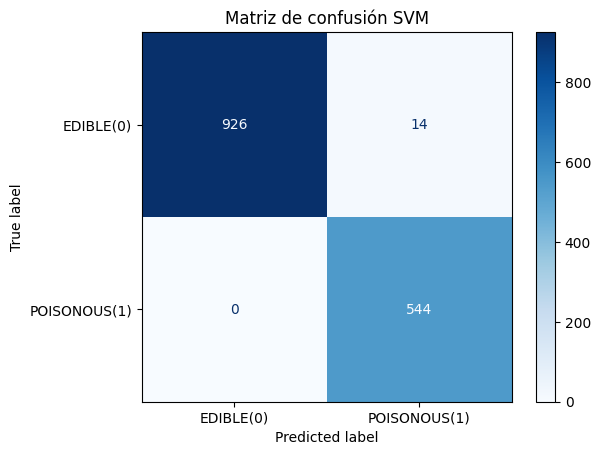

In [101]:
disp_SVM = ConfusionMatrixDisplay(
    confusion_matrix=cm_SVM,
    display_labels=['EDIBLE(0)','POISONOUS(1)']
)
disp_SVM.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión SVM")
plt.show()

### Conclusiones

Utilizando este modelo se pueden observar los mejores resultados que se han obtenido hasta el momento, con un

### kernel Polinómico

Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

Para el caso de una función polinómica, también se busca conseguir fronteras de decisión curvas pero, en este caso, la complejidad de la curva se controlará con el grado del polinomio. Este modelo se suele utilizar para aquellos casos en los que la frontera no es lineal, pero tampoco es extremadamente complicada.

In [102]:
Score_poly = np.zeros(10)
Posicion_poly = np.zeros(10)
Time_poly = np.zeros(10)
for i in range(1,11):  
    Score_ind=np.zeros(5)
    Posicion_ind=np.zeros(5)
    Time_ind=np.zeros(5)
    for u in range (1,6):
        ini = time.time() 
        
        clf_svm = svm.SVC(C=i,kernel='poly')
        clf_svm.fit(X_train, y_train) 
        y_predict_svm = clf_svm.predict(X_test)
    
        Score_ind[u-1] = clf_svm.score(X_test, y_test)
        Posicion_ind[u-1] = i
        Time_ind[u-1] = (time.time() - ini)*1000
    Time_poly[i-1] = np.max(Time_ind)
    Score_poly[i-1] = np.max(Score_ind)
    Posicion_poly[i-1] = i
    print(f"Tiempo entrenamiento para C={i}  = {Time_poly[i-1]} ms") 
    print("Exactitud media obtenida con SVM para C={i}: ".format(i=i), clf_svm.score(X_test, y_test))

Tiempo entrenamiento para C=1  = 22.388935089111328 ms
Exactitud media obtenida con SVM para C=1:  0.9110512129380054
Tiempo entrenamiento para C=2  = 19.034385681152344 ms
Exactitud media obtenida con SVM para C=2:  0.9171159029649596
Tiempo entrenamiento para C=3  = 18.28765869140625 ms
Exactitud media obtenida con SVM para C=3:  0.9191374663072777
Tiempo entrenamiento para C=4  = 18.557071685791016 ms
Exactitud media obtenida con SVM para C=4:  0.9150943396226415
Tiempo entrenamiento para C=5  = 19.84548568725586 ms
Exactitud media obtenida con SVM para C=5:  0.9157681940700808
Tiempo entrenamiento para C=6  = 19.30403709411621 ms
Exactitud media obtenida con SVM para C=6:  0.9123989218328841
Tiempo entrenamiento para C=7  = 19.704580307006836 ms
Exactitud media obtenida con SVM para C=7:  0.9137466307277629
Tiempo entrenamiento para C=8  = 20.99776268005371 ms
Exactitud media obtenida con SVM para C=8:  0.9137466307277629
Tiempo entrenamiento para C=9  = 21.135568618774414 ms
Exact

In [103]:
Valor_maximo = np.max(Score_poly)
Tiempo_min = np.min(Time_poly)

print(f"El valor máximo de exactitud es de: {Valor_maximo}")
print(f"Y está situado en la posición: {Score_poly.argmax()}")
print(f"El valor mínimo de tiempo es de: {Tiempo_min}")
print(f"Y está situado en la posición: {Time_poly.argmin()}")

clf_svm = svm.SVC(C=Score_poly.argmax(),kernel='poly')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

El valor máximo de exactitud es de: 0.9191374663072777
Y está situado en la posición: 2
El valor mínimo de tiempo es de: 18.28765869140625
Y está situado en la posición: 2
Tiempo entrenamiento = 16.651 ms


### Entrenamiento
Utilizaremos el algoritmo <code>SVC</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC">documentación del algoritmo</a>). Es el algoritmo implementado en <b>scikit-learn</b> para clasificación de <code>SVM</code>.

In [104]:
clf_svm = svm.SVC(C=(Score_poly.argmax())+1,kernel='poly')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
clf_svm.fit(X_train, y_train) 
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms")

Tiempo entrenamiento = 16.792 ms


### Predicción
Ahora podemos utilizar nuestro modelo entrenado para realizar predicciones, para ello llamamos al método <code>predict</code> con el conjunto de valores que hemos reservado para test:

In [105]:
ini = time.time() 
y_predict_svm = clf_svm.predict(X_test)
print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

y_predict_svm [0:5] # muestra del resultado de la predicción

Tiempo de predicción = 1.802 ms


array([0, 0, 0, 1, 0])

## Matriz de confusión

Se muestra a continuación la matriz de confusión ya que esta gráfica nos permite ver fácilmente el número de elemetos que los algoritmos han clasificado correcta e incorrectamente. Para mostrarla utilizamos <code>ConfusionMatrixDisplay</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html">documentación</a>).

In [106]:
cm_SVM = confusion_matrix(y_test, y_predict_svm, labels=[0,1])
cm_SVM

array([[820, 120],
       [  0, 544]])

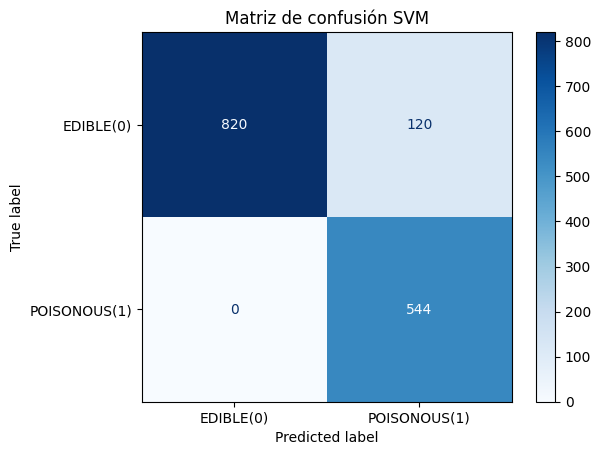

In [107]:
disp_SVM = ConfusionMatrixDisplay(
    confusion_matrix=cm_SVM,
    display_labels=['EDIBLE(0)','POISONOUS(1)']
)
disp_SVM.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión SVM")
plt.show()

### Conclusiones

A pesar de que los resultados son bastante buenos, se obtiene un 92% de precisión aproximadamente, se puede observar como el aumento de "C" no genera practicamente ningún tipo de cambio en los resultados obtenidos, unicamente en el aumento del tiempo de entrenamiento. Otro detalle a valorar es la diferencia en tiempos de entrenamiento entre los metodos "linear", "RBF" y "poly" ya que para el caso de la función polinómica, esta reduce considerablemente este tiempo de entrenamiento.

## CASOS A ESTUDIAR

1- TODO PREPROCESADO 
2- CONJUNTO DE DATOS BANILA 
3- SOLO BALANCEADO DE DATOS: TODO PREPROCESADO - PCA - NORMALIZADO
4- TODO PREPROCESADO - NORMALIZADO



<a name="classification"></a>
<div class="alert alert-block alert-info" 
     style="border: 0px solid #d60e8c; border-radius: 10px; background:#d60e8c; color: white;">
      <h2>Código preliminar y de pruebas</h2>
    <hr style="border: 0.5px solid #ffffff;">
   <ul style="margin-bottom: 20px;">
</div>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import preprocessing
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

df_orig=pd.read_csv('mushroms1.csv', na_values=["?"])
df_orig.head()
df_orig.isnull().sum()
df=df_orig.dropna(axis=0)
df.isnull().sum()

#Pasamos de texto a numero
encoder = preprocessing.OrdinalEncoder(dtype=int)
df_encoded = encoder.fit_transform(df[['poisonous', "cap-shape","cap-surface","cap-color","bruises","odor",
                                      "gill-attachment","gill-spacing","gill-size","gill-color","stalk-shape","stalk-root",
                                      "stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring",
                                      "stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type",
                                      "spore-print-color","population","habitat"]])
encoder.categories_
df_encoded
df["poisonous"] = df_encoded[:,0]
df["cap-shape"] = df_encoded[:,1]
df["cap-surface"] = df_encoded[:,2]
df["cap-color"] = df_encoded[:,3]
df["bruises"] = df_encoded[:,4]
df["odor"] = df_encoded[:,5]
df["gill-attachment"] = df_encoded[:,6]
df["gill-spacing"] = df_encoded[:,7]
df["gill-size"] = df_encoded[:,8]
df["gill-color"] = df_encoded[:,9]
df["stalk-shape"] = df_encoded[:,10]
df["stalk-root"] = df_encoded[:,11]
df["stalk-surface-above-ring"] = df_encoded[:,12]
df["stalk-surface-below-ring"] = df_encoded[:,13]
df["stalk-color-above-ring"] = df_encoded[:,14]
df["stalk-color-below-ring"] = df_encoded[:,15]
df["veil-type"] = df_encoded[:,16]
df["veil-color"] = df_encoded[:,17]
df["ring-number"] = df_encoded[:,18]
df["ring-type"] = df_encoded[:,19]
df["spore-print-color"] = df_encoded[:,20]
df["population"] = df_encoded[:,21]
df["habitat"] = df_encoded[:,22]
df.head()

df.shape
df['poisonous'].value_counts()
df.columns
feature_df = df[df.columns[1:df.shape[1]]]
X = feature_df


y = df['poisonous']

y[0:5] 

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Training set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

print ('Conjunto entrenamiento original', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

sm = NearMiss()
X_train, y_train= sm.fit_resample(X_train, y_train)


print('\nBalanceado:', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))



Score = np.zeros(99)
Posicion = np.zeros(99)
for i in range(1,100):
    k = i   
    

    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(X_train,y_train)
    y_predict_knn = neigh.predict(X_test)
    
    
    Score[i-1] = neigh.score(X_test, y_test)
    Posicion[i-1] = i
    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

Training set: (4748, 22) (4748,)
Test set: (1188, 22) (1188,)
Conjunto entrenamiento original (4748, 22) (4748,)
{np.int64(0): np.int64(3008), np.int64(1): np.int64(1740)}

Balanceado: (3480, 22) (3480,)
{np.int64(0): np.int64(1740), np.int64(1): np.int64(1740)}
Exactitud media obtenida con k-NN para k=1:  0.9806397306397306
Exactitud media obtenida con k-NN para k=2:  0.9806397306397306
Exactitud media obtenida con k-NN para k=3:  0.9747474747474747
Exactitud media obtenida con k-NN para k=4:  0.9747474747474747
Exactitud media obtenida con k-NN para k=5:  0.9705387205387206
Exactitud media obtenida con k-NN para k=6:  0.9688552188552189
Exactitud media obtenida con k-NN para k=7:  0.9562289562289562
Exactitud media obtenida con k-NN para k=8:  0.9570707070707071
Exactitud media obtenida con k-NN para k=9:  0.9562289562289562
Exactitud media obtenida con k-NN para k=10:  0.9562289562289562
Exactitud media obtenida con k-NN para k=11:  0.9537037037037037
Exactitud media obtenida con k-

In [ ]:
for i in range(1, 100):
    k = i

    # Creamos nuestra instancia del modelo
    neigh = KNeighborsClassifier(n_neighbors = k)

    ini = time.time() 
    #Entrenamiento del modelo, llamando a su método fit 
    neigh.fit(X_train,y_train)
    #print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

    ini = time.time() 
    y_predict_knn = neigh.predict(X_test)
    #print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

    y_predict_knn[0:5] # muestra del resultado de la predicción

    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

<br/><br/>
<hr style="border: 0.5px solid #d60e8c;">
<div style="text-align:right;">
MASTER UNIVERSITARIO EN INGENIERÍA INDUSTRIAL
</div>